[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana10_Valuacion_Opciones_FFT.ipynb)

# Articulo base:

[Schmeltze (2010) Fourier Pricing. Full title: Option Pricing formulae using Fourier Transform: Theory and Applications](https://pfadintegral.com/docs/Schmelzle2010%20Fourier%20Pricing.pdf)

Recordemos, una propiedad de la función característica (en la teoría de probabilidad) es su relación uno a uno con la función de distribución. Esto significa que una única función característica le corresponde una unica función de distribución [Waller (1995)], y el converso de esto es el Teorema de la teoría de funciones características, que nos da la función característica de una distribución de probabiliad por medio de la transformada de Fourier inversa.

# Valuación de opciones con la transformada de Fourier

Valuaremos Opciones de tipo call Europeo, utilizando el modelo de Black-Scholes y comparandolo con el modelo que utiliza la transformada de Fourier


Referencia: Dr. Yves J. Hilpisch, "Derivatives Analytics with Python" (2015)

In [ ]:
!git clone https://github.com/mcf-long-short/option-pricing-fourier-transform.git

Cloning into 'option-pricing-fourier-transform'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 73 (delta 23), reused 48 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 82.65 KiB | 4.35 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [ ]:
cd /content/option-pricing-fourier-transform

/content/option-pricing-fourier-transform


In [ ]:
!pip install requests_cache

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.4 MB/s eta 0:00:00


# Al igual que la clase anterior, solucionaremos manualmente un problema de compatibilidad

In [ ]:
!cat /content/option-pricing-fourier-transform/options/models/bsm_fourier.py

from numpy.fft import fft
from scipy.integrate import quad
import numpy as np

from .base import OptionPricingModel


class BSMForierTransformPricing(OptionPricingModel):

    @staticmethod
    def bsm_integral_function(u, S0, K, T, r, sigma):
        """ 
        Valuation of European call option in BSM model via Lewis (2001)
        Fourier-based approach: integral function. 
        """
        cf_value = BSMForierTransformPricing.bsm_characteristic_function(u - 1j * 0.5, 0.0, T, r, sigma)  # noqa
        int_value = 1 / (u ** 2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * cf_value).real  # noqa
        return int_value

    @staticmethod
    def bsm_characteristic_function(v, x0, T, r, sigma):
        """
        Valuation of European call option in BSM model via Lewis (2001) and Carr-Madan (1999)
        Fourier-based approach: charcteristic function. 
        """
        cf_value = np.exp(((x0 / T + r - 0.5 * sigma ** 2) * 1j * v - 0.5 * sigma ** 2 * v ** 2) * T)  # noqa
        

In [ ]:
%%writefile /content/option-pricing-fourier-transform/options/models/bsm_fourier.py
from numpy.fft import fft
from scipy.integrate import quad
import numpy as np

from .base import OptionPricingModel


class BSMForierTransformPricing(OptionPricingModel):

    @staticmethod
    def bsm_integral_function(u, S0, K, T, r, sigma):
        """
        Valuation of European call option in BSM model via Lewis (2001)
        Fourier-based approach: integral function.
        """
        cf_value = BSMForierTransformPricing.bsm_characteristic_function(u - 1j * 0.5, 0.0, T, r, sigma)  # noqa
        int_value = 1 / (u ** 2 + 0.25) * (np.exp(1j * u * np.log(S0 / K)) * cf_value).real  # noqa
        return int_value

    @staticmethod
    def bsm_characteristic_function(v, x0, T, r, sigma):
        """
        Valuation of European call option in BSM model via Lewis (2001) and Carr-Madan (1999)
        Fourier-based approach: charcteristic function.
        """
        cf_value = np.exp(((x0 / T + r - 0.5 * sigma ** 2) * 1j * v - 0.5 * sigma ** 2 * v ** 2) * T)  # noqa
        return cf_value


class BSM_FT_NUM(BSMForierTransformPricing):
    """Fourier option pricing - Lewis Approach (2001)

    Class implementing calculation for European option price using Forier Transform
    via Lewis Approach (numberical integration).

    Reference: Dr. Yves J. Hilpisch, Derivatives Analytics with Python
    """

    def _calculate_call_option_price(self, S, K, T, r, sigma):
        """ Valuation of European call option in BSM model via Lewis (2001)

        Parameters
        ==========
        S: float
            initial stock/index level
        K: float
            strike price
        T: float
            time-to-maturity (for t=0)
        r: float
            constant risk-free short rate
        sigma: float
            volatility factor in diffusion term

        Returns
        =======
        call_value: float
            European call option present value
        """
        int_value = quad(lambda u: self.bsm_integral_function(u, S, K, T, r, sigma), 0, 100)[0]  # noqa
        call_value = max(0, S - np.exp(-r * T) * np.sqrt(S * K) / np.pi * int_value)  # noqa
        return call_value


class BSM_FFT(BSMForierTransformPricing):
    """Fourier option pricing - Lewis Approach (2001)

    Class implementing calculation for European option price using Forier Transform
    via Lewis Approach (FFT - Fast Forier Transform).

    Reference: Dr. Yves J. Hilpisch, Derivatives Analytics with Python
    """

    def _calculate_call_option_price(self, S, K, T, r, sigma):
        """Valuation of European call option in BSM model via Lewis (2001)
        Fourier-based approach (integral).

        Parameters
        ==========
        S: float
            initial stock/index level
        K: float
            strike price
        T: float
            time-to-maturity (for t=0)
        r: float
            constant risk-free short rate
        sigma: float
            volatility factor in diffusion term

        Returns
        =======
        call_value: float
            European call option present value

        """
        k = np.log(K / S)
        x0 = np.log(S / S)
        g = 1  # factor to increase accuracy
        N = g * 4096
        eps = (g * 150.) ** -1
        eta = 2 * np.pi / (N * eps)
        b = 0.5 * N * eps - k
        u = np.arange(1, N + 1, 1)
        vo = eta * (u - 1)
        # Modificatons to Ensure int_valueegrability
        if S >= 0.95 * K:  # ITM case
            alpha = 1.5
            v = vo - (alpha + 1) * 1j
            modcharFunc = np.exp(-r * T) * (self.bsm_characteristic_function(
                v, x0, T, r, sigma) /
                (alpha ** 2 + alpha
                 - vo ** 2 + 1j * (2 * alpha + 1) * vo))
        else:        # OTM case
            alpha = 1.1
            v = (vo - 1j * alpha) - 1j
            modcharFunc1 = np.exp(-r * T) * (1 / (1 + 1j * (vo - 1j * alpha))
                                             - np.exp(r * T) /
                                             (1j * (vo - 1j * alpha))
                                             - self.bsm_characteristic_function(
                v, x0, T, r, sigma) /
                ((vo - 1j * alpha) ** 2
                 - 1j * (vo - 1j * alpha)))
            v = (vo + 1j * alpha) - 1j
            modcharFunc2 = np.exp(-r * T) * (1 / (1 + 1j * (vo + 1j * alpha))
                                             - np.exp(r * T) /
                                             (1j * (vo + 1j * alpha))
                                             - self.bsm_characteristic_function(
                v, x0, T, r, sigma) /
                ((vo + 1j * alpha) ** 2
                 - 1j * (vo + 1j * alpha)))
        # Numerical FFT Routine
        delt = np.zeros(N)
        delt[0] = 1
        j = np.arange(1, N + 1, 1)
        SimpsonW = (3 + (-1) ** j - delt) / 3
        if S >= 0.95 * K:
            FFTFunc = np.exp(1j * b * vo) * modcharFunc * eta * SimpsonW
            payoff = (fft(FFTFunc)).real
            CallValueM = np.exp(-alpha * k) / np.pi * payoff
        else:
            FFTFunc = (np.exp(1j * b * vo)
                       * (modcharFunc1 - modcharFunc2)
                       * 0.5 * eta * SimpsonW)
            payoff = (fft(FFTFunc)).real
            CallValueM = payoff / (np.sinh(alpha * k) * np.pi)
        pos = int((k + b) / eps)
        CallValue = CallValueM[pos] * S
        # klist = np.exp((np.arange(0, N, 1) - 1) * eps - b) * S0
        return CallValue  # , klist[pos - 50:pos + 50]

Overwriting /content/option-pricing-fourier-transform/options/models/bsm_fourier.py


# Dependencias

In [ ]:
import math
from time import time

import numpy as np
import matplotlib.pyplot as plt

# Módulos locales
from options.models.bsm import BSM
from options.models.bsm_fourier import BSM_FT_NUM
from options.models.bsm_fourier import BSM_FFT

In [ ]:
# Parámetros del modelo

S0 = 100.00     # Precio actual del activo
K = 100.00      # Strike firmado en el contrato
T = 1           # Tiempo de expiración de la opción (medido en años)
r = 0.05        # Tasa libre de riesgo
sigma = 0.2     # Volatilidad


In [ ]:
np.linspace(S0 * 0.6, S0 * 1.4, 50)

array([ 60.        ,  61.63265306,  63.26530612,  64.89795918,
        66.53061224,  68.16326531,  69.79591837,  71.42857143,
        73.06122449,  74.69387755,  76.32653061,  77.95918367,
        79.59183673,  81.2244898 ,  82.85714286,  84.48979592,
        86.12244898,  87.75510204,  89.3877551 ,  91.02040816,
        92.65306122,  94.28571429,  95.91836735,  97.55102041,
        99.18367347, 100.81632653, 102.44897959, 104.08163265,
       105.71428571, 107.34693878, 108.97959184, 110.6122449 ,
       112.24489796, 113.87755102, 115.51020408, 117.14285714,
       118.7755102 , 120.40816327, 122.04081633, 123.67346939,
       125.30612245, 126.93877551, 128.57142857, 130.20408163,
       131.83673469, 133.46938776, 135.10204082, 136.73469388,
       138.36734694, 140.        ])

## Comparison between Lewis method and BSM analytical formula

Valuation accuracy of Lewis’ integral approach in comparison to BSM analytical formula; parameter values are S0 = 100, T = 1.0, r = 0.05, 𝜎 = 0.2

In [ ]:
def plot_val_differences_bsm(vtype='int'):
    k_list = np.linspace(S0 * 0.6, S0 * 1.4, 50)
    ana_values = BSM().price('call', S0, k_list, T, r, sigma)
    plt.figure(figsize=(8, 6))
    plt.subplot(311)
    plt.plot(k_list, ana_values, 'b', label='analytical', lw=1.5)
    if vtype == 'int':
        int_values = np.array([BSM_FT_NUM().price('call', S0, K, T, r, sigma)
                               for K in k_list])
        plt.plot(k_list, int_values, 'r-.', label='Fourier (integral)', lw=1.5)
        diffs = int_values - ana_values
        rdiffs = (int_values - ana_values) / ana_values
    elif vtype == 'fft':
        fft_values = np.array([BSM_FFT().price('call', S0, K, T, r, sigma)
                               for K in k_list])
        plt.plot(k_list, fft_values, 'r-.', label='Fourier (FFT)', lw=1.5)
        diffs = fft_values - ana_values
        rdiffs = (fft_values - ana_values) / ana_values
    plt.legend()
    plt.grid()
    plt.subplot(312)
    plt.plot(k_list, diffs, 'g', label='abs. difference', lw=1.5)
    plt.legend(loc=0)
    plt.grid()
    plt.subplot(313)
    plt.plot(k_list, rdiffs, 'r', label='rel. difference', lw=1.5)
    plt.legend(loc=0)
    plt.xlabel('strike')
    plt.grid()
    plt.tight_layout()


Black-Scholes style: pagina 17

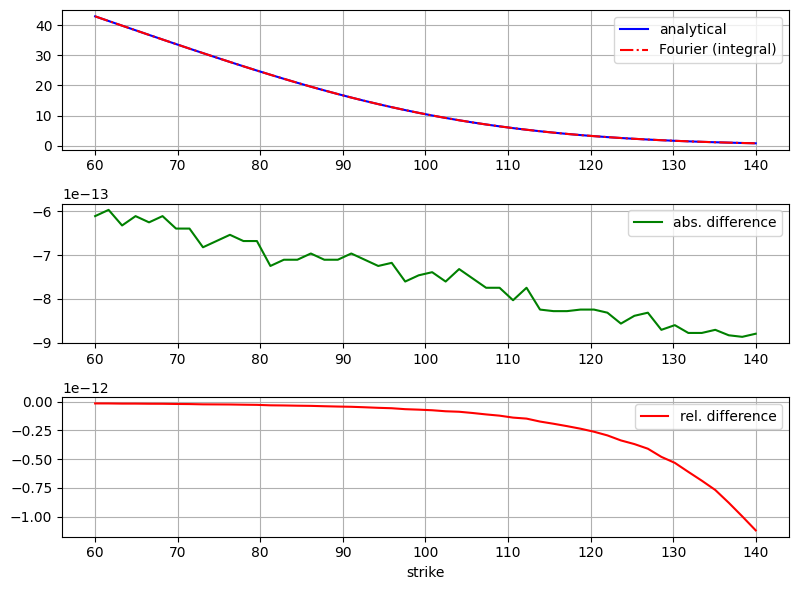

In [ ]:
plot_val_differences_bsm(vtype='int')

LEWIS: pagina 25

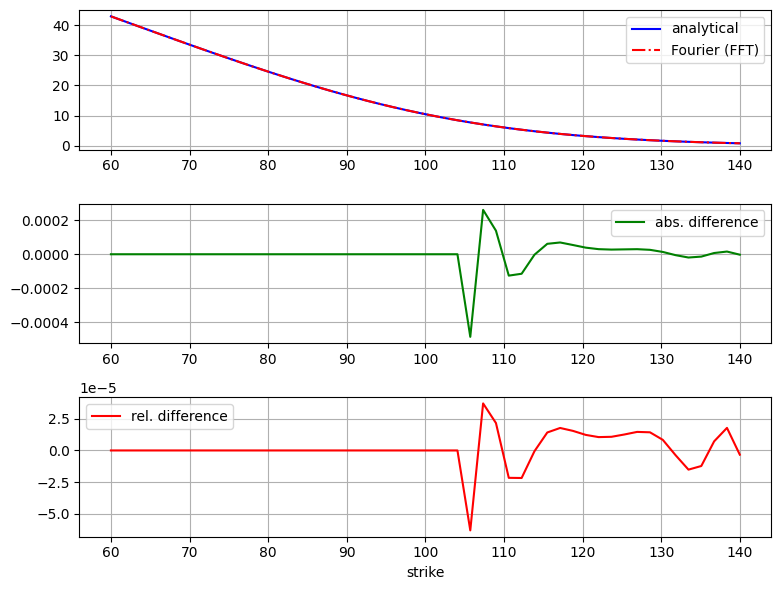

In [ ]:
plot_val_differences_bsm(vtype='fft')

## Option Pricing with DFT/FFT Speed Test

Pricing using Fast Fourier Transform Algorithm on Binomial model

In [ ]:
def get_binomial_parameters(M=100):
    # Time Parameters
    dt = T / M              # Length of time interval
    df = math.exp(-r * dt)  # Discount per interval

    # Binomial Parameters
    u = math.exp(sigma * math.sqrt(dt))     # Up movement
    d = 1 / u                               # Down movement
    q = (math.exp(r * dt) - d) / (u - d)    # Risk neutral probability
    return dt, df, u, d, q

In [ ]:
from numpy.fft import fft, ifft

In [ ]:
# Parmeter Adjustments
M=101
dt, df, u, d, q = get_binomial_parameters(M)

In [ ]:
u

1.020100083748034

In [ ]:
mu = np.arange(M + 1)
mu = np.resize(mu, (M + 1, M + 1))
md = np.transpose(mu)

(mu - md)

array([[   0,    1,    2, ...,   99,  100,  101],
       [  -1,    0,    1, ...,   98,   99,  100],
       [  -2,   -1,    0, ...,   97,   98,   99],
       ...,
       [ -99,  -98,  -97, ...,    0,    1,    2],
       [-100,  -99,  -98, ...,   -1,    0,    1],
       [-101, -100,  -99, ...,   -2,   -1,    0]])

In [ ]:
# Array Generation for Stock Prices
mu = np.arange(M + 1)
mu = np.resize(mu, (M + 1, M + 1))
md = np.transpose(mu)
mu = u ** (mu - md)
md = d ** md
S = S0 * mu * md

In [ ]:
S.shape

(102, 102)

In [ ]:
# Valuation by FFT
CT = np.maximum(S[:, -1] - K, 0)
qv = np.zeros(M + 1, dtype=float)
qv[0] = q
qv[1] = 1 - q
option_price = fft(math.exp(-r * T) * ifft(CT) * fft(qv) ** M)

In [ ]:
def call_fft_value(M):
    from numpy.fft import fft, ifft

    # Parmeter Adjustments
    dt, df, u, d, q = get_binomial_parameters(M)

    # Array Generation for Stock Prices
    mu = np.arange(M + 1)
    mu = np.resize(mu, (M + 1, M + 1))
    md = np.transpose(mu)
    mu = u ** (mu - md)
    md = d ** md
    S = S0 * mu * md

    # Valuation by FFT
    CT = np.maximum(S[:, -1] - K, 0)
    qv = np.zeros(M + 1, dtype=float)
    qv[0] = q
    qv[1] = 1 - q
    option_price = fft(math.exp(-r * T) * ifft(CT) * fft(qv) ** M)

    return option_price

In [ ]:
start = time()
precios = call_fft_value(1000)
elapsed_time = np.round(time() - start, 2)
print(f"Elapsed time for 1000 steps: {elapsed_time}s")

Elapsed time for 1000 steps: 0.1s


In [ ]:
start = time()
call_fft_value(5000)
elapsed_time = np.round(time() - start, 2)
print(f"Elapsed time for 5000 steps: {elapsed_time}s")

Elapsed time for 5000 steps: 2.12s


In [ ]:
start = time()
call_fft_value(10000)
elapsed_time = np.round(time() - start, 2)
print(f"Elapsed time for 10000 steps: {elapsed_time}s")

Elapsed time for 10000 steps: 10.34s


# Referencias:

Paper: https://pfadintegral.com/docs/Schmelzle2010%20Fourier%20Pricing.pdf

Github: https://github.com/mcf-long-short/option-pricing-fourier-transform/tree/main